# MATH2603 Lab — ANN Part II: Backpropagation & Universal Approximation
## Forward pass · Loss · Gradients · Gradient checking · Training loop · Function approximation

### Run rule
- **Do not skip around.** Run from the top, one cell at a time (**Shift+Enter**).
- If something looks “undefined”, it usually means an earlier cell didn’t run.


## 0) Setup check (run first)

If you see `ModuleNotFoundError`, install from a terminal (Anaconda Prompt / cmd / PowerShell):

```bash
pip install numpy matplotlib
```


In [144]:
%pip install -U numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [145]:
import sys
print("Python:", sys.version.split()[0])

import numpy as np
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)


Python: 3.9.6
numpy: 2.0.2
matplotlib: 3.9.4


## Helper functions

In [146]:
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

def dsigmoid(a):
    # a = sigmoid(z); derivative wrt z is a(1-a)
    return a*(1-a)

def mse_loss(y_pred, y_true):
    # Mean squared error (scalar)
    return 0.5*np.mean((y_pred - y_true)**2)

def set_seed(seed=0):
    np.random.seed(seed)

def plot_loss_curve(losses, title="Loss curve"):
    plt.figure(figsize=(6,4))
    plt.plot(losses)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title(title)
    plt.show()


# Part A — Forward pass (manual)

Network:
- Input: 2
- Hidden: 3 sigmoid units
- Output: 1 sigmoid unit


In [147]:
set_seed(1)

# XOR dataset
X = np.array([[0.0,0.0],
              [0.0,1.0],
              [1.0,0.0],
              [1.0,1.0]], dtype=float)

y = np.array([[0.0],[1.0],[1.0],[0.0]], dtype=float)

# Parameters
W1 = 0.5*np.random.randn(2, 3)
b1 = np.zeros(3)
W2 = 0.5*np.random.randn(3, 1)
b2 = np.zeros(1)

print("Shapes:", W1.shape, b1.shape, W2.shape, b2.shape)


Shapes: (2, 3) (3,) (3, 1) (1,)


In [148]:
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    y_hat = sigmoid(z2)
    cache = {"z1": z1, "a1": a1, "z2": z2, "y_hat": y_hat}
    return y_hat, cache

y_hat, cache = forward(X, W1, b1, W2, b2)
loss = mse_loss(y_hat, y)

print("Predictions (y_hat):\n", np.round(y_hat, 3))
print("Loss:", loss)


Predictions (y_hat):
 [[0.581]
 [0.532]
 [0.625]
 [0.58 ]]
Loss: 0.1291654990099904


### Task A1 (write 4–7 sentences)
1. What are the shapes of z1, a1, z2, y_hat?
2. Why do we apply a nonlinear activation after the weighted sum?
3. If everything were linear, what would happen to the model’s ability?


**Your answer here:**


# Part B — Numerical gradients (finite differences)

dL/dw ≈ [L(w+eps) − L(w−eps)] / (2eps)


In [149]:
def loss_with_params(X, y, W1, b1, W2, b2):
    y_hat, _ = forward(X, W1, b1, W2, b2)
    return mse_loss(y_hat, y)

def numerical_grad_W2(X, y, W1, b1, W2, b2, eps=1e-5):
    grad = np.zeros_like(W2)
    for i in range(W2.shape[0]):
        for j in range(W2.shape[1]):
            W2_pos = W2.copy(); W2_neg = W2.copy()
            W2_pos[i, j] += eps
            W2_neg[i, j] -= eps
            L_pos = loss_with_params(X, y, W1, b1, W2_pos, b2)
            L_neg = loss_with_params(X, y, W1, b1, W2_neg, b2)
            grad[i, j] = (L_pos - L_neg) / (2*eps)
    return grad

num_gW2 = numerical_grad_W2(X, y, W1, b1, W2, b2, eps=1e-5)
print("Numerical gradient dL/dW2:\n", np.round(num_gW2, 6))


Numerical gradient dL/dW2:
 [[0.011823]
 [0.0095  ]
 [0.008052]]


### Task B1
Change eps to 1e-4 and 1e-6. Does the gradient change? Why might extremely small eps be unstable?


**Your answer here:**


# Part C — Backpropagation (analytic gradients)

We compute analytic gradients with backprop and compare to numerical gradients.


In [150]:
def backprop(X, y, W1, b1, W2, b2):
    N = X.shape[0]
    y_hat, cache = forward(X, W1, b1, W2, b2)
    a1 = cache["a1"]

    dL_dyhat = (y_hat - y) / N
    dL_dz2 = dL_dyhat * dsigmoid(y_hat)

    dW2 = a1.T @ dL_dz2
    db2 = np.sum(dL_dz2, axis=0)

    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * dsigmoid(a1)

    dW1 = X.T @ dL_dz1
    db1 = np.sum(dL_dz1, axis=0)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

grads = backprop(X, y, W1, b1, W2, b2)
print("Backprop gradient dL/dW2:\n", np.round(grads["dW2"], 6))


Backprop gradient dL/dW2:
 [[0.011823]
 [0.0095  ]
 [0.008052]]


In [151]:
num_gW2 = numerical_grad_W2(X, y, W1, b1, W2, b2, eps=1e-5)
bp_gW2 = grads["dW2"]

abs_diff = np.abs(num_gW2 - bp_gW2)
print("Numerical dW2:\n", np.round(num_gW2, 6))
print("Backprop  dW2:\n", np.round(bp_gW2, 6))
print("Max abs diff:", abs_diff.max())


Numerical dW2:
 [[0.011823]
 [0.0095  ]
 [0.008052]]
Backprop  dW2:
 [[0.011823]
 [0.0095  ]
 [0.008052]]
Max abs diff: 1.2845471214495419e-12


### Task C1
If the gradient check fails (difference large), what are likely causes? Write 4–7 sentences.


**Your answer here:**


# Part D — Training loop (gradient descent)


lr = 0.1
Final predictions: [[0.403 0.524 0.521 0.566]]
Final loss: 0.11733224678323655

lr = 0.5
Final predictions: [[0.079 0.914 0.915 0.1  ]]
Final loss: 0.0038644641542022323

lr = 1.0
Final predictions: [[0.039 0.961 0.961 0.044]]
Final loss: 0.0008114447329894546

lr = 2.0
Final predictions: [[0.024 0.977 0.977 0.025]]
Final loss: 0.00028328792512058096



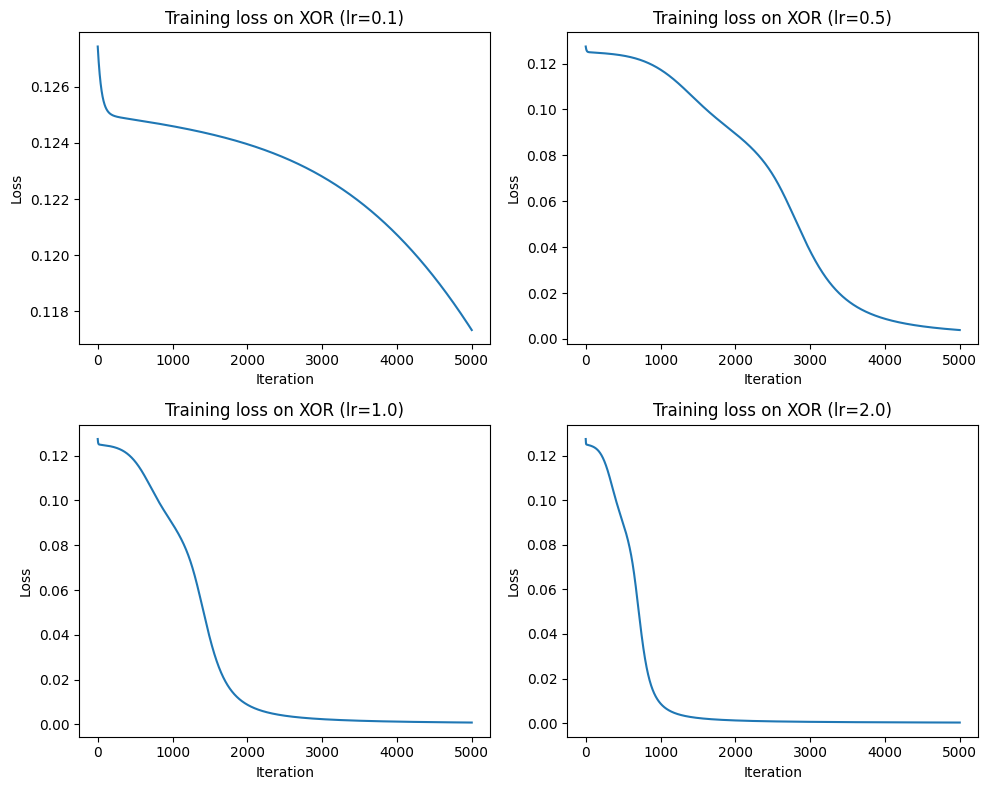

In [152]:
def train_xor(X, y, hidden=3, lr=1.0, iters=4000, seed=2):
    set_seed(seed)
    W1 = 0.5*np.random.randn(2, hidden)
    b1 = np.zeros(hidden)
    W2 = 0.5*np.random.randn(hidden, 1)
    b2 = np.zeros(1)

    losses = []
    for t in range(iters):
        y_hat, _ = forward(X, W1, b1, W2, b2)
        L = mse_loss(y_hat, y)
        losses.append(L)

        grads = backprop(X, y, W1, b1, W2, b2)
        W1 -= lr * grads["dW1"]
        b1 -= lr * grads["db1"]
        W2 -= lr * grads["dW2"]
        b2 -= lr * grads["db2"]

    return W1, b1, W2, b2, losses

lrs = [0.1, 0.5, 1.0, 2.0]
iters = 5000

plt.figure(figsize=(10, 8))

for i, lr in enumerate(lrs, 1):
    W1_t, b1_t, W2_t, b2_t, losses = train_xor(X, y, hidden=3, lr=lr, iters=iters, seed=2)

    plt.subplot(2, 2, i)
    plt.plot(losses)
    plt.title(f"Training loss on XOR (lr={lr})")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")

    y_hat, _ = forward(X, W1_t, b1_t, W2_t, b2_t)
    print(f"lr = {lr}")
    print("Final predictions:", np.round(y_hat.T, 3))
    print("Final loss:", losses[-1])
    print()

plt.tight_layout()
plt.show()


### Task D1
Try at least 3 learning rates. Write 6–10 sentences:
- What did the loss curve look like for each?    
For lr = 0.1, the loss decreased very slowly and stayed relatively high.  
For lr = 0.5, it decreased more clearly and reached a much lower value.  
For lr = 1.0 and lr = 2.0, the loss dropped faster and converged close to zero.  
Overall, all four curves went downward, but larger learning rates converged faster. Learning rate controls the step size in training, so it affects convergence speed. 

- What happened when lr was too small / too large?  
In my results, lr = 0.1 was too small because training was very slow and the final loss remained high.  
The larger values worked better here because they reduced the loss much faster.  
However, the larger rates I tested were not too large, since they still converged smoothly and did not diverge.  
So in this experiment, the main difference was convergence speed rather than instability. Neural-network training uses gradient-based updates, and the learning rate determines how large each update step is. 


**Your answer here:**


# Part E — Universal Approximation intuition (function fitting)

We fit a function with a 1-hidden-layer network:
- Input x ∈ [-1,1]
- Target: sin(3πx) + 0.3x (plus noise)
- Sigmoid hidden units + **linear output** (regression)


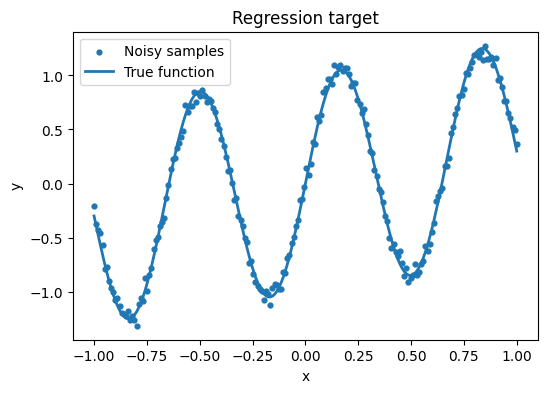

In [153]:
set_seed(0)
N = 200
x = np.linspace(-1, 1, N).reshape(-1, 1)
y_true = (np.sin(3*np.pi*x) + 0.3*x)
y_reg = y_true + 0.05*np.random.randn(N, 1)

plt.figure(figsize=(6,4))
plt.scatter(x, y_reg, s=12, label="Noisy samples")
plt.plot(x, y_true, linewidth=2, label="True function")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression target")
plt.legend()
plt.show()


In [154]:
def forward_reg(x, W1, b1, W2, b2):
    z1 = x @ W1 + b1
    a1 = sigmoid(z1)
    y_hat = a1 @ W2 + b2  # linear output
    cache = {"a1": a1, "y_hat": y_hat}
    return y_hat, cache

def mse_loss_reg(y_hat, y):
    return 0.5*np.mean((y_hat - y)**2)

def backprop_reg(x, y, W1, b1, W2, b2):
    N = x.shape[0]
    y_hat, cache = forward_reg(x, W1, b1, W2, b2)
    a1 = cache["a1"]

    dL_dyhat = (y_hat - y) / N  # (N,1)

    dW2 = a1.T @ dL_dyhat
    db2 = np.sum(dL_dyhat, axis=0)

    dL_da1 = dL_dyhat @ W2.T
    dL_dz1 = dL_da1 * dsigmoid(a1)

    dW1 = x.T @ dL_dz1
    db1 = np.sum(dL_dz1, axis=0)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}, y_hat

def train_reg(x, y, H=10, lr=1.0, iters=6000, seed=1):
    set_seed(seed)
    W1 = 0.8*np.random.randn(1, H)
    b1 = np.zeros(H)
    W2 = 0.8*np.random.randn(H, 1)
    b2 = np.zeros(1)

    losses = []
    for t in range(iters):
        grads, y_hat = backprop_reg(x, y, W1, b1, W2, b2)
        L = mse_loss_reg(y_hat, y)
        losses.append(L)

        W1 -= lr * grads["dW1"]
        b1 -= lr * grads["db1"]
        W2 -= lr * grads["dW2"]
        b2 -= lr * grads["db2"]

    return W1, b1, W2, b2, losses


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_21492/2361171637.py:4: RuntimeWarning: divide by zero encountered in matmul
  y_hat = a1 @ W2 + b2  # linear output
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_21492/2361171637.py:4: RuntimeWarning: overflow encountered in matmul
  y_hat = a1 @ W2 + b2  # linear output
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_21492/2361171637.py:4: RuntimeWarning: invalid value encountered in matmul
  y_hat = a1 @ W2 + b2  # linear output
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_21492/2361171637.py:18: RuntimeWarning: divide by zero encountered in matmul
  dW2 = a1.T @ dL_dyhat
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_21492/2361171637.py:18: RuntimeWarning: overflow encountered in matmul
  dW2 = a1.T @ dL_dyhat
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_21492/2361171637.py:18: RuntimeWarning: invalid value encountered in matmul
  dW2 = a1.T @ dL_dyhat
/var/fold

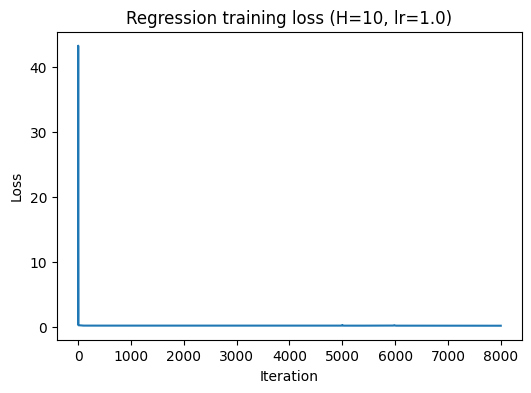

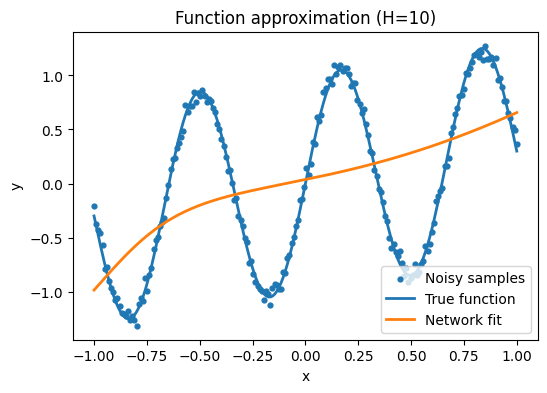

In [155]:
H = 10   # TODO: try 3, 10, 30
lr = 1.0   # TODO: try 0.5, 1.0
iters = 8000

W1r, b1r, W2r, b2r, losses_r = train_reg(x, y_reg, H=H, lr=lr, iters=iters, seed=1)
plot_loss_curve(losses_r, title=f"Regression training loss (H={H}, lr={lr})")

y_fit, _ = forward_reg(x, W1r, b1r, W2r, b2r)

plt.figure(figsize=(6,4))
plt.scatter(x, y_reg, s=12, label="Noisy samples")
plt.plot(x, y_true, linewidth=2, label="True function")
plt.plot(x, y_fit, linewidth=2, label="Network fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Function approximation (H={H})")
plt.legend()
plt.show()


### Task E1 (UAT intuition)
Write 6–10 sentences:
1. How does increasing H affect the fit?
2. Why might too large H be risky on noisy data?
3. In your own words, what does “universal approximation” mean in practice?


**Your answer here:**


---
## Troubleshooting
- If plots do not show in VS Code, try running in browser Jupyter, or add `%matplotlib inline` near the top.
- If you see `overflow encountered in exp`, reduce the learning rate `lr`.
